# Layer3 + Layer4 Fine-Tuning

This notebook studies deeper partial fine-tuning of an ImageNet-pretrained ResNet-50 on the Oxford-IIIT Pet classification task.

The previous experiment, E2, allowed only `Layer4` and the classification head to adapt.

In E3, we additionally unfreeze `Layer3`.

The experiment is:

$$
\boxed{
\text{E3 — Layer3 + Layer4 Fine-Tuning}
}
$$

The main research question is:

> **Does allowing deeper feature adaptation improve the model's ability to represent the target pet-breed task?**

The trainable parameter progression is:

```mermaid
flowchart LR
    A["E1: FC Only"] --> B["E2: Layer4 + FC"]
    B --> C["E3: Layer3 + Layer4 + FC"]
```

E3 is therefore an intermediate point between feature extraction and full fine-tuning.


## Experiment Configuration

The dataset and optimization protocol remain unchanged.

Configuration:

- 37-class Oxford-IIIT Pet classification
- Official `trainval` / `test` split
- Stratified 80/20 train-validation split
- Fixed random seed of 42
- Input resolution of $224\times224$
- Same training and evaluation transforms
- Batch size of 16
- 30 epochs
- AdamW
- Learning rate $10^{-3}$
- Weight decay $10^{-4}$
- Cosine annealing scheduler

The only experimental change is the set of trainable layers.

E2:

$$
\theta_{\text{trainable}}
=
\theta_{Layer4}
\cup
\theta_{FC}
$$

E3:

$$
\theta_{\text{trainable}}
=
\theta_{Layer3}
\cup
\theta_{Layer4}
\cup
\theta_{FC}
$$

This keeps the experiment focused on the effect of increasing fine-tuning depth.


In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import ResNet50_Weights, resnet50


SEED = 42

DATA_ROOT = Path("../data/raw")

IMAGE_SIZE = 224

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

BATCH_SIZE = 16
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()

NUM_EPOCHS = 30

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Seed:", SEED)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Seed: 42
Device: cuda
GPU: NVIDIA GeForce GTX 1650


## Dataset Setup

The same dataset protocol is maintained for E3.

The official test set remains isolated from model selection.

```mermaid
flowchart LR
    A["Oxford-IIIT Pet"] --> B["TrainVal"]
    A --> C["Test"]

    B --> D["Train"]
    B --> E["Validation"]

    D --> F["Optimization"]
    E --> G["Checkpoint Selection"]
    C --> H["Final Evaluation"]
```


In [2]:
dataset_trainval = OxfordIIITPet(
    root=DATA_ROOT,
    split="trainval",
    target_types="category",
    download=False,
)

dataset_test = OxfordIIITPet(
    root=DATA_ROOT,
    split="test",
    target_types="category",
    download=False,
)

indices = np.arange(len(dataset_trainval))
labels = np.array(dataset_trainval._labels)

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=SEED,
    stratify=labels,
)

print("Train samples:", len(train_indices))
print("Validation samples:", len(val_indices))
print("Test samples:", len(dataset_test))
print("Classes:", len(dataset_trainval.classes))


Train samples: 2944
Validation samples: 736
Test samples: 3669
Classes: 37


## Image Preprocessing

The preprocessing pipeline remains unchanged.

Training uses the same baseline augmentation:

```mermaid
flowchart LR
    A["Original Image"] --> B["RandomResizedCrop"]
    B --> C["RandomHorizontalFlip"]
    C --> D["ToTensor"]
    D --> E["ImageNet Normalization"]
    E --> F["224 × 224 Tensor"]
```

Validation and test use deterministic preprocessing:

```text
Resize → CenterCrop → ToTensor → Normalize
```

No new augmentation is introduced in E3.

This ensures that the main difference between E2 and E3 is fine-tuning depth.


In [3]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])


In [4]:
class OxfordPetSubset(Dataset):
    def __init__(
        self,
        base_dataset,
        indices,
        transform=None,
    ):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        real_index = self.indices[index]
        image, label = self.base_dataset[real_index]

        if self.transform is not None:
            image = self.transform(image)

        return image, label


train_dataset = OxfordPetSubset(
    base_dataset=dataset_trainval,
    indices=train_indices,
    transform=train_transform,
)

val_dataset = OxfordPetSubset(
    base_dataset=dataset_trainval,
    indices=val_indices,
    transform=eval_transform,
)

test_dataset = OxfordPetSubset(
    base_dataset=dataset_test,
    indices=np.arange(len(dataset_test)),
    transform=eval_transform,
)


In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Label range:", labels.min().item(), labels.max().item())


Images shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Label range: 1 35


## Load ImageNet-Pretrained ResNet-50

E3 starts from the same ImageNet-pretrained ResNet-50 used in E1 and E2.

The classifier is replaced with a 37-class head.

The ResNet hierarchy is:

```mermaid
flowchart LR
    A["Conv1"] --> B["Layer1"]
    B --> C["Layer2"]
    C --> D["Layer3"]
    D --> E["Layer4"]
    E --> F["Global Average Pool"]
    F --> G["FC"]
```

E3 keeps `Conv1`, `Layer1`, and `Layer2` frozen, while allowing `Layer3`, `Layer4`, and `FC` to adapt.


In [6]:
weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

print("Loaded ImageNet-pretrained ResNet-50.")


Loaded ImageNet-pretrained ResNet-50.


## Replace the Classification Head

The ImageNet classifier is replaced with a 37-class classifier.

$$
\mathbb{R}^{2048}
\rightarrow
\mathbb{R}^{37}
$$

The new classifier is trainable.


In [7]:
num_classes = 37

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes,
)


## Freeze and Unfreeze Parameters

E3 uses the following configuration:

| Component | Status |
|---|---|
| Conv1 | Frozen |
| Layer1 | Frozen |
| Layer2 | Frozen |
| Layer3 | Trainable |
| Layer4 | Trainable |
| FC | Trainable |

The parameter flow is:

```mermaid
flowchart LR
    A["Conv1"]:::frozen --> B["Layer1"]:::frozen
    B --> C["Layer2"]:::frozen
    C --> D["Layer3"]:::trainable
    D --> E["Layer4"]:::trainable
    E --> F["FC"]:::trainable

    classDef frozen stroke-dasharray: 5 5;
    classDef trainable stroke-width: 3;
```

This experiment allows the model to adapt both mid-level and high-level representations while preserving the earliest ImageNet features.


In [8]:
# Freeze the complete network first.
for parameter in model.parameters():
    parameter.requires_grad = False

# Unfreeze Layer3 and Layer4.
for parameter in model.layer3.parameters():
    parameter.requires_grad = True

for parameter in model.layer4.parameters():
    parameter.requires_grad = True

# Keep the new classifier trainable.
for parameter in model.fc.parameters():
    parameter.requires_grad = True

model = model.to(device)


## Verify Trainable Layers

The expected configuration is:

```text
Conv1   → Frozen
Layer1  → Frozen
Layer2  → Frozen
Layer3  → Trainable
Layer4  → Trainable
FC      → Trainable
```

The configuration is verified programmatically before training.


In [9]:
def count_parameters(module):
    total = sum(
        parameter.numel()
        for parameter in module.parameters()
    )

    trainable = sum(
        parameter.numel()
        for parameter in module.parameters()
        if parameter.requires_grad
    )

    return total, trainable


components = {
    "conv1": model.conv1,
    "layer1": model.layer1,
    "layer2": model.layer2,
    "layer3": model.layer3,
    "layer4": model.layer4,
    "fc": model.fc,
}

rows = []

for name, module in components.items():
    total, trainable = count_parameters(module)

    rows.append({
        "component": name,
        "total_params": total,
        "trainable_params": trainable,
        "trainable": trainable > 0,
    })

parameter_status = pd.DataFrame(rows)

parameter_status


,component,total_params,trainable_params,trainable
0,conv1,9408,0,False
1,layer1,215808,0,False
2,layer2,1219584,0,False
3,layer3,7098368,7098368,True
4,layer4,14964736,14964736,True
5,fc,75813,75813,True


## Trainable Parameter Count

The fine-tuning depth controls the size of the optimization space.

E2:

$$
\theta_{\text{trainable}}
=
\theta_{Layer4}
\cup
\theta_{FC}
$$

E3:

$$
\theta_{\text{trainable}}
=
\theta_{Layer3}
\cup
\theta_{Layer4}
\cup
\theta_{FC}
$$

Therefore:

$$
N_{E2}<N_{E3}<N_{E4}
$$

where E4 represents full fine-tuning.


In [10]:
total_params = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable ratio:      {trainable_params / total_params:.2%}")


Total parameters:     23,583,845
Trainable parameters: 22,138,917
Trainable ratio:      93.87%


## Why Unfreeze Layer3?

E3 allows the adaptation to reach one stage deeper into the network.

A simplified representation hierarchy is:

```mermaid
flowchart LR
    A["Early Features"] --> B["Edges / Textures"]
    B --> C["Shapes / Patterns"]
    C --> D["Layer3"]
    D --> E["Layer4"]
    E --> F["High-Level Semantics"]
    F --> G["Breed Classification"]
```

Layer3 is expected to contain richer mid-level representations than the earliest layers.

> **Hypothesis:** Allowing Layer3 and Layer4 to adapt may provide a better representation for fine-grained breed discrimination than adapting Layer4 alone.

Deeper adaptation also increases the number of trainable parameters and therefore the capacity to overfit or overwrite useful pretrained representations.


## Training Objective

Let the parameters be divided into:

$$
\theta=
\{
\theta_{early},
\theta_{L3},
\theta_{L4},
\theta_{FC}
\}
$$

where:

$$
\theta_{early}
=
\{
\theta_{conv1},
\theta_{L1},
\theta_{L2}
\}
$$

are frozen.

Thus:

$$
\theta_{early}^{new}
=
\theta_{early}^{old}
$$

while:

$$
\theta_{L3}^{new}
=
\theta_{L3}^{old}
-
\eta
\frac{\partial L}
{\partial\theta_{L3}}
$$

$$
\theta_{L4}^{new}
=
\theta_{L4}^{old}
-
\eta
\frac{\partial L}
{\partial\theta_{L4}}
$$

and:

$$
\theta_{FC}^{new}
=
\theta_{FC}^{old}
-
\eta
\frac{\partial L}
{\partial\theta_{FC}}
$$


## Optimizer

The optimization recipe remains unchanged from E2.

This keeps the E2 → E3 comparison focused on fine-tuning depth.

We do not introduce discriminative learning rates or additional regularization in this experiment.

$$
\eta=10^{-3}
$$

$$
\lambda=10^{-4}
$$


In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        model.parameters(),
    ),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
)


## Training Loop

The forward pass uses the complete network.

During backpropagation, only `Layer3`, `Layer4`, and `FC` receive parameter updates.

```mermaid
flowchart LR
    A["Input"] --> B["Frozen Conv1-Layer2"]
    B --> C["Trainable Layer3"]
    C --> D["Trainable Layer4"]
    D --> E["Trainable FC"]
    E --> F["Loss"]

    F --> G["Backward"]
    G --> H["Update Layer3"]
    G --> I["Update Layer4"]
    G --> J["Update FC"]
```


In [12]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


In [13]:
def evaluate(
    model,
    loader,
    criterion,
    device,
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)

            predictions = logits.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


## Training History

We record:

- training loss
- training accuracy
- validation loss
- validation accuracy
- learning rate

This allows the optimization dynamics of E3 to be examined after training.


In [14]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": [],
}


## Best Checkpoint

The best E3 checkpoint is selected using validation accuracy.

```mermaid
flowchart LR
    A["Epoch"] --> B["Validation Accuracy"]
    B --> C{"Improved?"}
    C -->|Yes| D["Save E3 Checkpoint"]
    C -->|No| E["Continue Training"]
```


In [15]:
checkpoint_dir = Path(
    "../experiments/checkpoints"
)

checkpoint_dir.mkdir(
    parents=True,
    exist_ok=True,
)

best_val_accuracy = 0.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )

    val_loss, val_accuracy = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["learning_rate"].append(current_lr)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy

        torch.save(
            {
                "experiment": "E3",
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_accuracy": val_accuracy,
            },
            checkpoint_dir
            / "resnet50_layer3_4_finetuning_best.pt",
        )

    scheduler.step()

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2%} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2%} | "
        f"LR: {current_lr:.2e}"
    )


Epoch [01/30] | Train Loss: 2.0545 | Train Acc: 40.76% | Val Loss: 1.2756 | Val Acc: 60.73% | LR: 1.00e-03
Epoch [02/30] | Train Loss: 1.2074 | Train Acc: 63.38% | Val Loss: 0.7379 | Val Acc: 77.45% | LR: 9.97e-04
Epoch [03/30] | Train Loss: 1.0458 | Train Acc: 67.53% | Val Loss: 0.8095 | Val Acc: 77.04% | LR: 9.89e-04
Epoch [04/30] | Train Loss: 0.8957 | Train Acc: 72.59% | Val Loss: 0.7027 | Val Acc: 78.67% | LR: 9.76e-04
Epoch [05/30] | Train Loss: 0.7759 | Train Acc: 76.39% | Val Loss: 0.6526 | Val Acc: 81.25% | LR: 9.57e-04
Epoch [06/30] | Train Loss: 0.7188 | Train Acc: 77.38% | Val Loss: 0.6023 | Val Acc: 81.11% | LR: 9.33e-04
Epoch [07/30] | Train Loss: 0.6666 | Train Acc: 79.45% | Val Loss: 0.5239 | Val Acc: 83.70% | LR: 9.05e-04
Epoch [08/30] | Train Loss: 0.6081 | Train Acc: 80.81% | Val Loss: 0.4505 | Val Acc: 85.05% | LR: 8.72e-04
Epoch [09/30] | Train Loss: 0.5445 | Train Acc: 82.81% | Val Loss: 0.4527 | Val Acc: 86.55% | LR: 8.35e-04
Epoch [10/30] | Train Loss: 0.5411 | 

## Load the Best E3 Checkpoint

After training, restore the checkpoint with the highest validation accuracy before evaluating the official test set.


In [16]:
checkpoint = torch.load(
    checkpoint_dir
    / "resnet50_layer3_4_finetuning_best.pt",
    map_location=device,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

best_epoch = checkpoint["epoch"]

print("Best epoch:", best_epoch)
print(
    "Best validation accuracy:",
    f"{checkpoint['val_accuracy']:.2%}",
)


Best epoch: 26
Best validation accuracy: 92.93%


## Learning Curves

The training curves are used to inspect the optimization dynamics.

We are interested in whether the additional trainable Layer3:

- improves optimization;
- improves validation performance;
- increases the train-validation gap;
- introduces signs of overfitting.


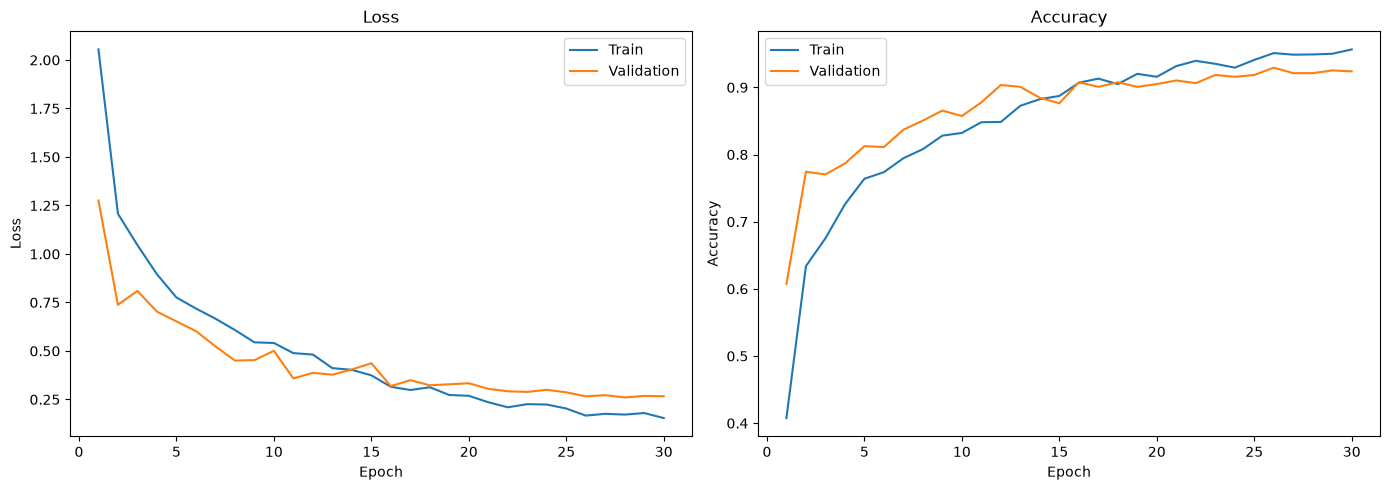

In [17]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

axes[0].plot(
    epochs,
    history["train_loss"],
    label="Train",
)

axes[0].plot(
    epochs,
    history["val_loss"],
    label="Validation",
)

axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(
    epochs,
    history["train_accuracy"],
    label="Train",
)

axes[1].plot(
    epochs,
    history["val_accuracy"],
    label="Validation",
)

axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## Validation Evaluation

The validation set is used to determine the best E3 checkpoint.

We report:

- validation loss
- validation accuracy
- best epoch


In [18]:
best_val_loss, best_val_accuracy = evaluate(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=device,
)

print(
    f"Best Validation Loss: "
    f"{best_val_loss:.4f}"
)

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy:.2%}"
)

print("Best Epoch:", best_epoch)


Best Validation Loss: 0.2658
Best Validation Accuracy: 92.93%
Best Epoch: 26


## Final Evaluation on the Test Set

After selecting the best E3 checkpoint using validation performance, we evaluate it once on the official test set.

The test set is not used for model selection or hyperparameter tuning.


In [19]:
test_loss, test_accuracy = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device,
)

print(f"E3 Test Loss: {test_loss:.4f}")
print(f"E3 Test Accuracy: {test_accuracy:.2%}")


E3 Test Loss: 0.4682
E3 Test Accuracy: 87.95%


## E3 Baseline Result

The E3 experiment records:

- trainable parameter count
- training configuration
- best epoch
- validation performance
- test performance
- fine-tuning strategy


In [20]:
e3_result = pd.DataFrame([{
    "experiment": "E3",
    "model": "ResNet-50",
    "initialization": "ImageNet",
    "trainable_params": trainable_params,
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "best_epoch": best_epoch,
    "best_val_accuracy": best_val_accuracy,
    "best_val_loss": best_val_loss,
    "test_accuracy": test_accuracy,
    "test_loss": test_loss,
    "strategy": "Layer3 + Layer4 Fine-Tuning",
}])

e3_result


,experiment,model,initialization,trainable_params,epochs,batch_size,learning_rate,weight_decay,best_epoch,best_val_accuracy,best_val_loss,test_accuracy,test_loss,strategy
0,E3,ResNet-50,ImageNet,22138917,30,16,0.001,0.0001,26,0.929348,0.265825,0.879531,0.468232,Layer3 + Layer4 Fine-Tuning


## Save E3 Experiment Result

The experiment result is stored immediately after final test evaluation.

The central result file is updated while avoiding duplicate E3 entries if the notebook is rerun.


In [21]:
results_dir = Path("../experiments/results")
results_dir.mkdir(parents=True, exist_ok=True)

e3_result.to_csv(
    results_dir / "e3_layer3_4_finetuning.csv",
    index=False,
)

results_path = results_dir / "experiment_results.csv"

if results_path.exists():
    existing_results = pd.read_csv(results_path)

    existing_results = existing_results[
        existing_results["experiment"] != "E3"
    ]

    experiment_results = pd.concat(
        [existing_results, e3_result],
        ignore_index=True,
    )
else:
    experiment_results = e3_result.copy()

experiment_results.to_csv(
    results_path,
    index=False,
)

experiment_results


,experiment,model,initialization,trainable_params,epochs,batch_size,learning_rate,weight_decay,best_epoch,best_val_accuracy,best_val_loss,test_accuracy,test_loss,strategy
0,E0,ResNet-50,Random,23583845,30,16,0.001,0.0001,30,0.338315,2.317437,0.288907,2.500295,NaN
1,E1,ResNet-50,ImageNet,75813,30,16,0.001,0.0001,16,0.937500,0.226684,0.911420,0.292235,Feature Extraction
2,E2,ResNet-50,ImageNet,15040549,30,16,0.001,0.0001,21,0.947011,0.214195,0.911965,0.366784,Layer4 + FC Fine-Tuning
3,E3,ResNet-50,ImageNet,22138917,30,16,0.001,0.0001,26,0.929348,0.265825,0.879531,0.468232,Layer3 + Layer4 Fine-Tuning


# Conclusions

E3 increases the adaptation depth of the ImageNet-pretrained ResNet-50.

The configuration is:

$$
\boxed{
\text{Layer3}
+
\text{Layer4}
+
\text{FC}
\text{ trainable}
}
$$

while:

$$
\boxed{
\text{Conv1, Layer1, Layer2}
\text{ remain frozen}
}
$$

The main purpose of E3 is to determine whether deeper feature adaptation is useful for fine-grained pet-breed classification.

The next experiment removes the remaining freezing constraint:

> **E4 — Full Fine-Tuning**
